###################################
# Group ID : 420
# Members : Matias Mose,  Henrik Paaske Lind, Amalie Koch Andersen, Phillip Kaasgaard Sperling
# Date : 26-03-2025
# Lecture: Lecture 11: Graphic Models
# Dependencies: None
# Python version: 3.12
# Functionality: This code loads the housing dataset and extracts the input and outut data. That outputdata is thresholded based on the mean value of the target label, making it possible to perform binary classification. four different models are trained 2 classification and 2 regression models (Decision Tree And Random Forrest). The models are compared visually in terms of accuracy and R^2 and mean squared error. Finally, all tree depths from 1-50 is experimented with, to visualize the performance using different tree depths.
# .
# ###################################

is ### Imports

In [70]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from matplotlib import pyplot as plt
import seaborn as sns


### Unpack dataset


In [58]:
california_housing = fetch_california_housing(as_frame=True)

data_train = california_housing.data

data_target = california_housing.target



### Split data into 80% training and 20% testing

In [59]:
X_train, X_test, y_train, y_test = train_test_split(data_train, data_target, test_size=0.2, random_state=42)

## **Classification exercise**

In [60]:
mean_value_threshold = np.mean(y_train)
print("Threshold value for labeling data: " + str(mean_value_threshold))

Threshold value for labeling data: 2.071946937378876


### Binarize output for classificaiton

In [61]:
# Create binary class labels
y_train_labels = (y_train > mean_value_threshold).astype(int) # Returns a boolean array (True = 1, False = 0)
y_test_labels = (y_test > mean_value_threshold).astype(int)

### Decision Tree classification model

In [63]:
# Train
clf_tree = DecisionTreeClassifier(random_state=42)
clf_tree.fit(X_train, y_train_labels)

# Predict
y_pred_cls_tree = clf_tree.predict(X_test)
accuracy_score_tree = accuracy_score(y_test_labels, y_pred_cls_tree)
# Evaluate
print("Decision Tree Classifier Accuracy:", str(accuracy_score_tree))

Decision Tree Classifier Accuracy: 0.8309108527131783


### Random Forest classification model

In [64]:
# Train
clf_rf = RandomForestClassifier(random_state=42)
clf_rf.fit(X_train, y_train_labels)

# Predict
y_pred_cls_rf = clf_rf.predict(X_test)

accuracy_score_rf = accuracy_score(y_test_labels, y_pred_cls_rf)

# Evaluate
print("Random Forest Classifier Accuracy:", str(accuracy_score_rf))

Random Forest Classifier Accuracy: 0.8902616279069767


## **Regression Exercise**


### Decision Tree Regressor

In [71]:
# Train
reg_tree = DecisionTreeRegressor(random_state=42)
reg_tree.fit(X_train, y_train)

# Predict
y_pred_reg_tree = reg_tree.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_reg_tree)
r2_score_tree = r2_score(y_test, y_pred_cls_tree)
# Evaluate
print("Decision Tree Regressor MSE:", str(mse_tree) + "\n" +
      "Decision Tree Regressor R^2:", str(r2_score_tree))

Decision Tree Regressor MSE: 0.495235205629094
Decision Tree Regressor R^2: -1.7255675549219367


### Random Forest Regressor

In [72]:
# Train
reg_rf = RandomForestRegressor(random_state=42)
reg_rf.fit(X_train, y_train)

# Predict
y_pred_reg_rf = reg_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_reg_rf)
r2_score_rf = r2_score(y_test, y_pred_cls_rf)
# Evaluate
print("Random Forest Regressor MSE:", str(mse_rf) + "\n" +
      "Random Forest Regressor R^2:", str(r2_score_rf))

Random Forest Regressor MSE: 0.2553684927247781
Random Forest Regressor R^2: -1.7099501970521325


### Visualization and comparison

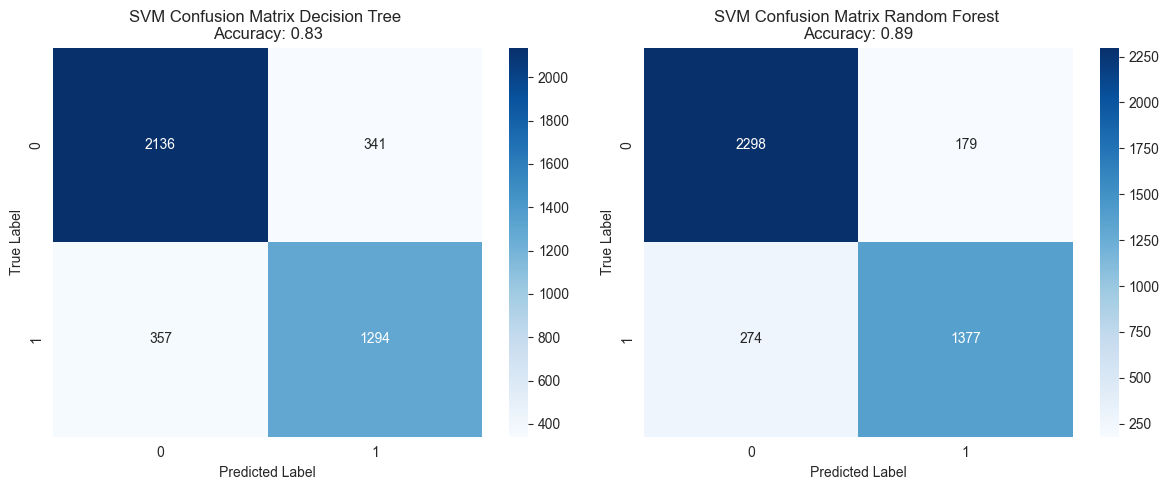


📋 Classification Report Tree :
              precision    recall  f1-score   support

     Class 0       0.86      0.86      0.86      2477
     Class 1       0.79      0.78      0.79      1651

    accuracy                           0.83      4128
   macro avg       0.82      0.82      0.82      4128
weighted avg       0.83      0.83      0.83      4128


 📋 Classification Report Random Forest:
              precision    recall  f1-score   support

     Class 0       0.89      0.93      0.91      2477
     Class 1       0.88      0.83      0.86      1651

    accuracy                           0.89      4128
   macro avg       0.89      0.88      0.88      4128
weighted avg       0.89      0.89      0.89      4128



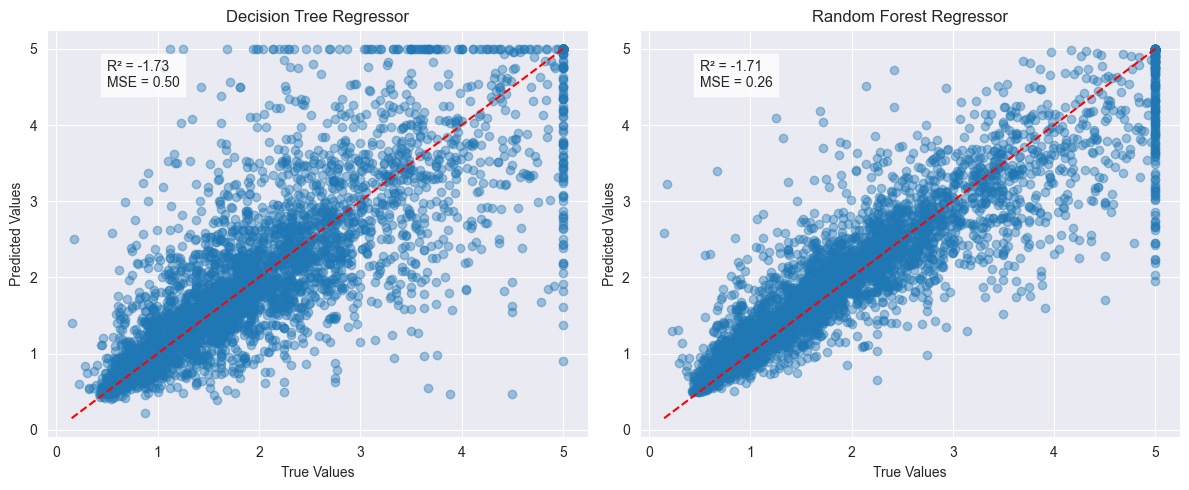

In [74]:
# Confusion Matrices
cm_clf_tree = confusion_matrix(y_test_labels, y_pred_cls_tree)
cm_clf_rf = confusion_matrix(y_test_labels, y_pred_cls_rf)

# Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_clf_tree, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(2), yticklabels=range(2), ax=axes[0])
axes[0].set_title(f"SVM Confusion Matrix Decision Tree \nAccuracy: {accuracy_score_tree:.2f}")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_clf_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(2), yticklabels=range(2), ax=axes[1])
axes[1].set_title(f"SVM Confusion Matrix Random Forest \nAccuracy: {accuracy_score_rf:.2f}")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# Classification report
report_clf_tree = classification_report(y_test_labels, y_pred_cls_tree, target_names=[f"Class {i}" for i in range(2)])
report_clf_rf = classification_report(y_test_labels, y_pred_cls_rf, target_names=[f"Class {i}" for i in range(2)])
print("\n📋 Classification Report Tree :")
print(report_clf_tree)

print("\n 📋 Classification Report Random Forest:")
print(report_clf_rf)

# Scatter plots with annotations
plt.figure(figsize=(12, 5))
# Decision Tree Regressor
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_reg_tree, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Decision Tree Regressor")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.text(0.5, 4.5, f"R² = {r2_score_tree:.2f}\nMSE = {mse_tree:.2f}",
         fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# Random Forest Regressor
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_reg_rf, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest Regressor")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.text(0.5, 4.5, f"R² = {r2_score_rf:.2f}\nMSE = {mse_rf:.2f}",
         fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### Experimenting with tree depth

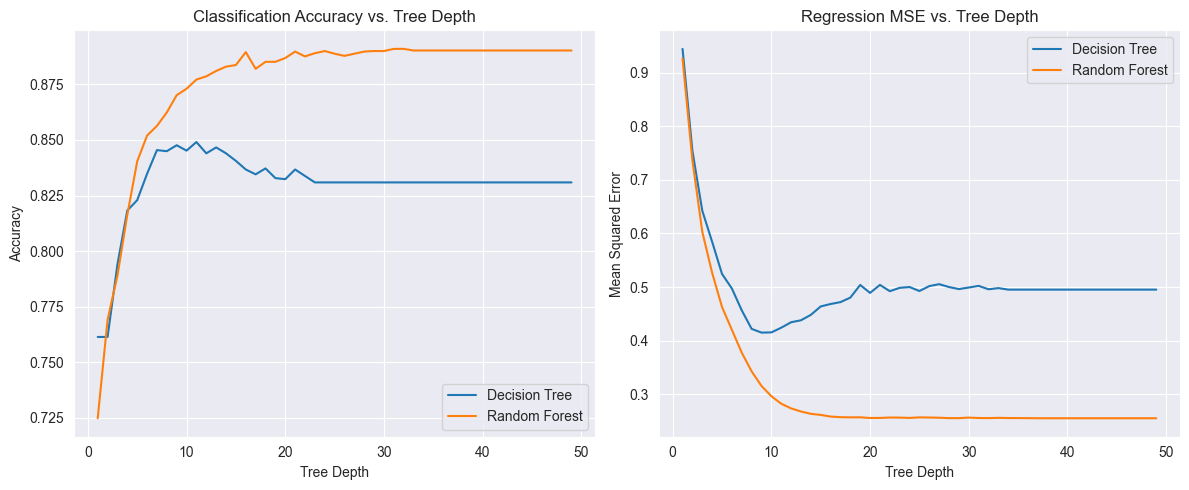

In [77]:
# Track performance for different depths
depths = range(1, 50)
acc_tree_list, acc_rf_list = [], []
mse_tree_list, mse_rf_list = [], []

for depth in depths:
    # Classification models
    dt_clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    rf_clf = RandomForestClassifier(max_depth=depth, n_estimators=100, random_state=42)
    dt_clf.fit(X_train, y_train_labels)
    rf_clf.fit(X_train, y_train_labels)
    acc_tree_list.append(accuracy_score(y_test_labels, dt_clf.predict(X_test)))
    acc_rf_list.append(accuracy_score(y_test_labels, rf_clf.predict(X_test)))

    # Regression models
    dt_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    rf_reg = RandomForestRegressor(max_depth=depth, n_estimators=100, random_state=42)
    dt_reg.fit(X_train, y_train)
    rf_reg.fit(X_train, y_train)
    mse_tree_list.append(mean_squared_error(y_test, dt_reg.predict(X_test)))
    mse_rf_list.append(mean_squared_error(y_test, rf_reg.predict(X_test)))

# Plotting Classification Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(depths, acc_tree_list, label="Decision Tree")
plt.plot(depths, acc_rf_list, label="Random Forest")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy vs. Tree Depth")
plt.legend()
plt.grid(True)

# Plotting Regression MSE
plt.subplot(1, 2, 2)
plt.plot(depths, mse_tree_list, label="Decision Tree")
plt.plot(depths, mse_rf_list, label="Random Forest")
plt.xlabel("Tree Depth")
plt.ylabel("Mean Squared Error")
plt.title("Regression MSE vs. Tree Depth")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()